# Modelagem de Sobrevida - LUAD

In [182]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

In [183]:
try:
    import torch
    import torchtuples as tt

    from pycox.models import CoxPH, DeepHitSingle
    from pycox.evaluation import EvalSurv

    deep_ok = True

except Exception as e:
    deep_ok = False
    print( e)

In [184]:
cohort = "LUAD"

project_dir = Path("..").resolve()

data_path = project_dir / "data" / "processed" / "luad" / "luad_modeling_dataset.csv"

results_dir = project_dir / "reports" / "results" / "luad"
figures_dir = project_dir / "reports" / "figures" / "luad"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42
n_splits = 5

In [185]:
print(data_path)

df = pd.read_csv(data_path, sep=";")

print("Shape:", df.shape)
df.head()

/workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_modeling_dataset.csv
Shape: (502, 94)


,patient_id,surv__OS.time,surv__OS,clin__age_at_index.demographic,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,clin__pack_years_smoked.exposures,clin__cigarettes_per_day.exposures,clin__age_at_index.demographic_missing,clin__age_at_earliest_diagnosis_in_years.diagnoses.xena_derived_missing,clin__pack_years_smoked.exposures_missing,...,S100A10,PIM2,PSME3,CCL20,IKBKB,MIF,FGFR2,LTBR,MET,AGRN
0,TCGA-05-4249,1523.0,0,67.0,67.210959,52.0,2.849315,0,0,0,...,12.2821,10.3286,11.6354,6.5895,12.2902,11.5286,9.1224,10.0792,13.1655,12.8819
1,TCGA-05-4250,121.0,1,79.0,79.638356,47.0,2.575342,0,0,0,...,14.6910,9.3912,12.0324,6.7385,10.1049,12.0569,6.6602,10.6575,13.0816,12.4818
2,TCGA-05-4382,607.0,0,68.0,68.131507,62.0,3.397260,0,0,0,...,15.0031,11.6397,11.6540,10.9371,10.0478,12.7837,9.5406,11.9222,9.9056,14.2954
3,TCGA-05-4384,426.0,0,66.0,66.879452,20.0,1.095890,0,0,0,...,13.3755,8.6719,11.2958,6.8330,10.7145,11.6035,8.4121,11.2125,11.8909,13.4724
4,TCGA-05-4389,1369.0,0,70.0,70.301370,43.0,2.356164,0,0,0,...,14.0021,9.7883,11.9159,8.7170,10.9728,13.1209,7.4608,11.6193,9.9740,11.9684


In [186]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

In [187]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(30)

Total de nulos: 0


Series([], dtype: int64)

In [188]:
df[event_col] = df[event_col].astype(int)
df[time_col] = df[time_col].astype(float)

print(df[event_col].value_counts())

print( round(df[event_col].mean() * 100, 2), "%")

print("Mínimo:", df[time_col].min())
print("Mediana:", df[time_col].median())
print("Máximo:", df[time_col].max())

surv__OS
0    320
1    182
Name: count, dtype: int64
36.25 %
Mínimo: 4.0
Mediana: 656.5
Máximo: 7248.0


In [189]:
feature_cols = [
    c for c in df.columns
    if c not in [time_col, event_col]
]

feature_cols = [
    c for c in feature_cols
    if "vital_status" not in c.lower()
]

X = df[feature_cols].copy()
tempo = df[time_col].copy()
evento = df[event_col].copy()


In [190]:
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

folds = list(skf.split(X, evento))

print("Quantidade de folds:", len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        ", teste =", len(test_idx),
        ", eventos teste =", int(evento.iloc[test_idx].sum())
    )

Quantidade de folds: 5
Fold 1: treino = 401 , teste = 101 , eventos teste = 37
Fold 2: treino = 401 , teste = 101 , eventos teste = 37
Fold 3: treino = 402 , teste = 100 , eventos teste = 36
Fold 4: treino = 402 , teste = 100 , eventos teste = 36
Fold 5: treino = 402 , teste = 100 , eventos teste = 36


## Pré-processamento dentro dos folds

In [191]:
def tirar_baixa_variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas = X_train.columns[seletor.get_support()]

    X_train_sel = pd.DataFrame(
        X_train_sel,
        columns=colunas,
        index=X_train.index
    )

    X_test_sel = pd.DataFrame(
        X_test_sel,
        columns=colunas,
        index=X_test.index
    )

    return X_train_sel, X_test_sel

In [192]:
def tirar_colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()

    matriz_superior = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [193]:
def padronizar_dados(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        X_test_scaled,
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_scaled, X_test_scaled

In [194]:
def preparar_fold(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    X_train_prep, X_test_prep = tirar_baixa_variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    X_train_prep, X_test_prep, removidas_corr = tirar_colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    if usar_scaler:
        X_train_prep, X_test_prep = padronizar_dados(
            X_train_prep,
            X_test_prep
        )

    return X_train_prep, X_test_prep, removidas_corr

In [195]:
def criar_y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [196]:
resultados_folds = []
resumo_modelos = []

def guardar_resultado(modelo, fold, c_train, c_test):
    resultados_folds.append({
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test
    })


def criar_resumo_modelo(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resumo = {
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resumo_modelos.append(resumo)

    return pd.DataFrame([resumo])

## Modelo 1 - CoxPH

In [197]:
nome_modelo = "CoxPH"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f" {nome_modelo} -  {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[time_col] = tempo_train.values
    df_train[event_col] = evento_train.values

    cox = CoxPHFitter(penalizer=1.0)
    cox.fit(df_train, duration_col=time_col, event_col=event_col)

    risco_train = cox.predict_partial_hazard(X_train_prep)
    risco_test = cox.predict_partial_hazard(X_test_prep)

    c_train = concordance_index(tempo_train, -risco_train, evento_train)
    c_test = concordance_index(tempo_test, -risco_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

 CoxPH -  1


C-index treino: 0.7357
C-index teste: 0.7766
 CoxPH -  2
C-index treino: 0.7615
C-index teste: 0.6569
 CoxPH -  3
C-index treino: 0.7429
C-index teste: 0.7447
 CoxPH -  4
C-index treino: 0.7528
C-index teste: 0.7043
 CoxPH -  5
C-index treino: 0.7531
C-index teste: 0.6893


In [198]:
resumo_cox = criar_resumo_modelo("CoxPH")
resumo_cox

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.749218,0.71436,0.046957,0.034858


## Modelo 2 - Weibull AFT

In [199]:
nome_modelo = "Weibull AFT"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f" {nome_modelo} -  {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[time_col] = tempo_train.values
    df_train[event_col] = evento_train.values

    aft = WeibullAFTFitter(penalizer=0.1)
    aft.fit(df_train, duration_col=time_col, event_col=event_col)

    pred_train = aft.predict_median(X_train_prep)
    pred_test = aft.predict_median(X_test_prep)

    pred_train = pred_train.replace([np.inf, -np.inf], np.nan)
    pred_test = pred_test.replace([np.inf, -np.inf], np.nan)

    pred_train = pred_train.fillna(pred_train.max())
    pred_test = pred_test.fillna(pred_test.max())

    c_train = concordance_index(tempo_train, pred_train, evento_train)
    c_test = concordance_index(tempo_test, pred_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

 Weibull AFT -  1


C-index treino: 0.7566
C-index teste: 0.7582
 Weibull AFT -  2
C-index treino: 0.7864
C-index teste: 0.6439
 Weibull AFT -  3
C-index treino: 0.7682
C-index teste: 0.7309
 Weibull AFT -  4
C-index treino: 0.7764
C-index teste: 0.6886
 Weibull AFT -  5
C-index treino: 0.7831
C-index teste: 0.6708


In [200]:
resumo_weibull = criar_resumo_modelo("Weibull AFT")
resumo_weibull

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,Weibull AFT,0.774148,0.698475,0.045983,0.075673


## Modelo 3 - Random Survival Forest

In [201]:
nome_modelo = "RSF"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f" {nome_modelo} -  {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    rsf = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=25,
        min_samples_leaf=20,
        max_features=5,
        n_jobs=-1,
        random_state=seed
    )

    rsf.fit(X_train_prep, y_train)

    risco_train = rsf.predict(X_train_prep)
    risco_test = rsf.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

 RSF -  1
C-index treino: 0.804
C-index teste: 0.7249
 RSF -  2
C-index treino: 0.8233
C-index teste: 0.6348
 RSF -  3
C-index treino: 0.801
C-index teste: 0.7229
 RSF -  4
C-index treino: 0.8079
C-index teste: 0.7326
 RSF -  5
C-index treino: 0.8121
C-index teste: 0.6759


In [202]:
resumo_rsf = criar_resumo_modelo("RSF")
resumo_rsf

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,RSF,0.809656,0.698236,0.041912,0.11142


## Modelo 4 - Gradient Boosting Survival Analysis

In [203]:
nome_modelo = "GBSA"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f" {nome_modelo} -  {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=150,
        learning_rate=0.02,
        max_depth=1,
        subsample=0.7,
        random_state=seed
    )

    gbsa.fit(X_train_prep, y_train)

    risco_train = gbsa.predict(X_train_prep)
    risco_test = gbsa.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

 GBSA -  1


C-index treino: 0.7456
C-index teste: 0.6961
 GBSA -  2
C-index treino: 0.766
C-index teste: 0.6819
 GBSA -  3
C-index treino: 0.7406
C-index teste: 0.7665
 GBSA -  4
C-index treino: 0.7515
C-index teste: 0.7196
 GBSA -  5
C-index treino: 0.7632
C-index teste: 0.6865


In [204]:
resumo_gbsa = criar_resumo_modelo("GBSA")
resumo_gbsa

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,GBSA,0.753377,0.7101,0.034696,0.043277


## Modelo 5 - DeepSurv

In [205]:
def preparar_dados_deep(X_train, X_test):
    X_train_deep = X_train.astype("float32").values
    X_test_deep = X_test.astype("float32").values

    return X_train_deep, X_test_deep

In [206]:
if deep_ok:
    nome_modelo = "DeepSurv"

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f" {nome_modelo} - {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("float32")
        evento_test = evento.iloc[test_idx].astype("float32")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        in_features = x_train_deep.shape[1]

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[16, 8],
            out_features=1,
            batch_norm=True,
            dropout=0.1
        )

        model = CoxPH(
            net,
            tt.optim.Adam
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            (tempo_train.values, evento_train.values),
            batch_size=32,
            epochs=100,
            callbacks=callbacks,
            val_data=(x_test_deep, (tempo_test.values, evento_test.values)),
            verbose=False
        )

        model.compute_baseline_hazards(
            input=x_train_deep,
            target=(tempo_train.values, evento_train.values)
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))

 DeepSurv - 1


C-index treino: 0.7585
C-index teste: 0.6917
 DeepSurv - 2
C-index treino: 0.8052
C-index teste: 0.5992
 DeepSurv - 3
C-index treino: 0.8105
C-index teste: 0.7017
 DeepSurv - 4
C-index treino: 0.7859
C-index teste: 0.6495
 DeepSurv - 5
C-index treino: 0.7645
C-index teste: 0.7063


In [207]:
if deep_ok:
    resumo_deepsurv = criar_resumo_modelo("DeepSurv")
    resumo_deepsurv

## Modelo 6 - DeepHit

In [208]:
if deep_ok:
    nome_modelo = "DeepHit"

    num_durations = 30

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f" {nome_modelo} - {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("int64")
        evento_test = evento.iloc[test_idx].astype("int64")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        labtrans = DeepHitSingle.label_transform(num_durations)

        y_train = labtrans.fit_transform(
            tempo_train.values,
            evento_train.values
        )

        y_test = labtrans.transform(
            tempo_test.values,
            evento_test.values
        )

        in_features = x_train_deep.shape[1]
        out_features = labtrans.out_features

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[32, 16],
            out_features=out_features,
            batch_norm=True,
            dropout=0.1
        )

        model = DeepHitSingle(
            net,
            tt.optim.Adam,
            alpha=0.5,
            sigma=0.1,
            duration_index=labtrans.cuts
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            y_train,
            batch_size=32,
            epochs=200,
            callbacks=callbacks,
            val_data=(x_test_deep, y_test),
            verbose=False
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))

 DeepHit - 1
C-index treino: 0.553
C-index teste: 0.5586
 DeepHit - 2
C-index treino: 0.6345
C-index teste: 0.6569
 DeepHit - 3
C-index treino: 0.6485
C-index teste: 0.5775
 DeepHit - 4
C-index treino: 0.6423
C-index teste: 0.588
 DeepHit - 5
C-index treino: 0.6435
C-index teste: 0.6281


In [209]:
if deep_ok:
    resumo_deephit = criar_resumo_modelo("DeepHit")
resumo_deephit

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepHit,0.624386,0.601822,0.039917,0.022564


In [210]:
df_resultados_folds = pd.DataFrame(resultados_folds)

df_resultados_folds

df_resultados_folds.to_csv(
    results_dir / "luad_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print( results_dir / "luad_resultados_por_fold.csv")

/workspaces/An-lise-de-Sobrevida/reports/results/luad/luad_resultados_por_fold.csv


In [211]:
df_resumo_modelos = pd.DataFrame(resumo_modelos)

df_resumo_modelos = df_resumo_modelos.sort_values(
    "c_index_teste_medio",
    ascending=False
).reset_index(drop=True)

df_resumo_modelos

df_resumo_modelos.to_csv(
    results_dir / "luad_resumo_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print( results_dir / "luad_resumo_modelos.csv")

/workspaces/An-lise-de-Sobrevida/reports/results/luad/luad_resumo_modelos.csv


In [212]:
tabela_tcc = df_resumo_modelos.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

tabela_tcc

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.7492,0.7144,0.0470,0.0349
1,GBSA,0.7534,0.7101,0.0347,0.0433
2,Weibull AFT,0.7741,0.6985,0.0460,0.0757
3,RSF,0.8097,0.6982,0.0419,0.1114
4,DeepSurv,0.7849,0.6697,0.0453,0.1152
5,DeepHit,0.6244,0.6018,0.0399,0.0226


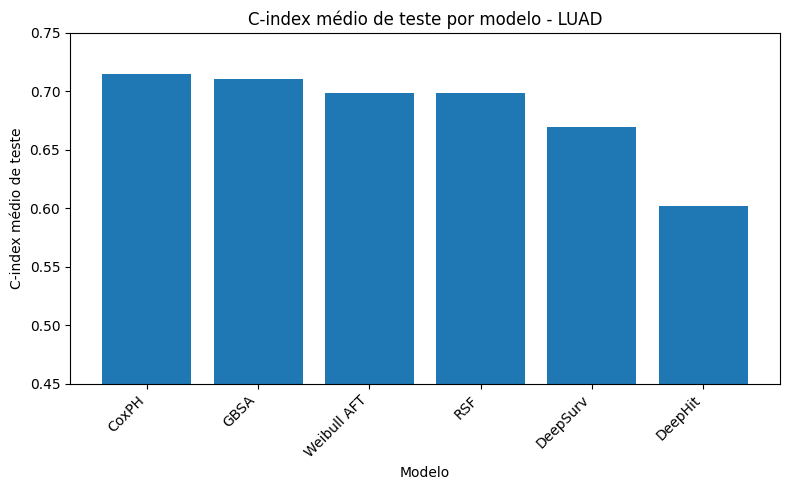

/workspaces/An-lise-de-Sobrevida/reports/figures/luad/luad_cindex_modelos.png


In [213]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["c_index_teste_medio"]
)

ax.set_title("C-index médio de teste por modelo - LUAD")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index médio de teste")
ax.set_ylim(0.45, 0.75)

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "luad_cindex_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "luad_cindex_modelos.png")

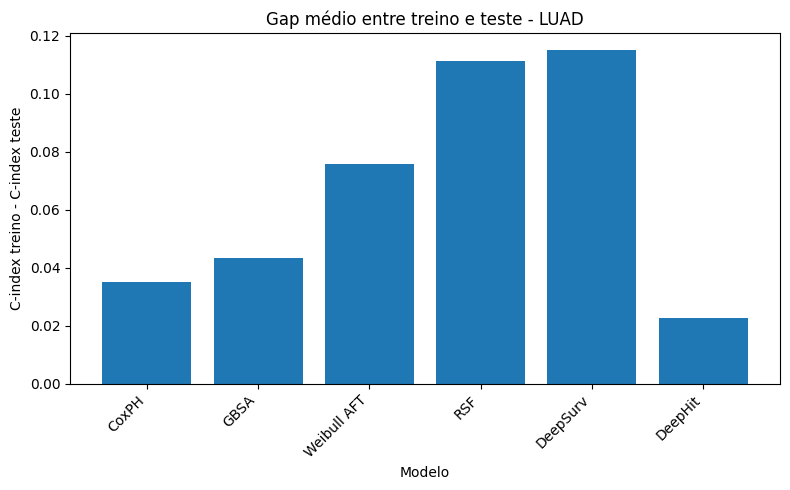

/workspaces/An-lise-de-Sobrevida/reports/figures/luad/luad_gap_modelos.png


In [214]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste - LUAD")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "luad_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print( figures_dir / "luad_gap_modelos.png")

In [215]:
tabela_latex = tabela_tcc.rename(columns={
    "modelo": "Modelo",
    "c_index_treino_medio": "C-index treino médio",
    "c_index_teste_medio": "C-index teste médio",
    "dp_teste": "DP teste",
    "gap_medio": "Gap"
})

print(
    tabela_latex.to_latex(
        index=False,
        escape=False,
        float_format="%.4f"
    )
)

\begin{tabular}{lrrrr}
\toprule
Modelo & C-index treino médio & C-index teste médio & DP teste & Gap \\
\midrule
CoxPH & 0.7492 & 0.7144 & 0.0470 & 0.0349 \\
GBSA & 0.7534 & 0.7101 & 0.0347 & 0.0433 \\
Weibull AFT & 0.7741 & 0.6985 & 0.0460 & 0.0757 \\
RSF & 0.8097 & 0.6982 & 0.0419 & 0.1114 \\
DeepSurv & 0.7849 & 0.6697 & 0.0453 & 0.1152 \\
DeepHit & 0.6244 & 0.6018 & 0.0399 & 0.0226 \\
\bottomrule
\end{tabular}



In [216]:
hiperparametros = pd.DataFrame([
    {
        "modelo": "CoxPH",
        "configuracao": "penalizer=1.0; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "Weibull AFT",
        "configuracao": "penalizer=0.1; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "RSF",
        "configuracao": "n_estimators=200; min_samples_split=25; min_samples_leaf=20; max_features=5; corr_threshold=0.90"
    },
    {
        "modelo": "GBSA",
        "configuracao": "n_estimators=150; learning_rate=0.02; max_depth=1; subsample=0.7; corr_threshold=0.90"
    },
    {
        "modelo": "DeepSurv",
        "configuracao": "MLP=[16,8]; dropout=0.1; batch_size=32; epochs=100; lr=0.001; early_stopping=10"
    },
    {
        "modelo": "DeepHit",
        "configuracao": "MLP=[32,16]; num_durations=30; alpha=0.5; sigma=0.1; batch_size=32; epochs=200; lr=0.001; early_stopping=10"
    },
])

hiperparametros

hiperparametros.to_csv(
    results_dir / "luad_hiperparametros.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

In [217]:
print("FINAL - MODELOS LUAD")

print("Base usada:", data_path)
print("Shape final:", df.shape)
print("Quantidade de features:", X.shape[1])
print("Quantidade de pacientes:", X.shape[0])
print("Eventos:", int(evento.sum()))
print("Taxa de eventos:", round(evento.mean() * 100, 2), "%")

print("Resultados gerados:")
for arquivo in sorted(results_dir.glob("*.csv")):
    print( arquivo.name)

print("Figuras geradas:")
for figura in sorted(figures_dir.glob("*.png")):
    print( figura.name)

FINAL - MODELOS LUAD
Base usada: /workspaces/An-lise-de-Sobrevida/data/processed/luad/luad_modeling_dataset.csv
Shape final: (502, 93)
Quantidade de features: 91
Quantidade de pacientes: 502
Eventos: 182
Taxa de eventos: 36.25 %
Resultados gerados:
luad_hiperparametros.csv
luad_resultados_por_fold.csv
luad_resumo_modelos.csv
lusc_hiperparametros.csv
lusc_resultados_por_fold.csv
lusc_resumo_modelos.csv
Figuras geradas:
luad_cindex_modelos.png
luad_clinical_profile.png
luad_gap_modelos.png
luad_kaplan_meier.png
